# Training Notebook

This Notebook is a proof of concept for the training approach. It uses random generated data and **not** NeuroGym. The sole purpose is to see a functional training loop using the custom code.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
from tqdm import tqdm

from src.models.ctrnn import CTRNN
from src.training.loss import compute_loss

### 1. Task Parameters & Dimensionality

**What:** Setting up the tensor shapes for our Continuous-Time RNN (CT-RNN).

**Why:** To ensure our architecture maps directly onto the *ContextDecisionMaking-v0* task. We use 7 input channels (e.g., 2 for context cues, 4 for sensory stimuli, 1 for fixation), 3 output classes, and the 80 hidden units specified in our proposal.

In [2]:
# 1. Setup Dummy Task Parameters (approximating Mante task dimensions)
batch_size = 64
seq_len = 50       # 50 timesteps * 20ms = 1000ms trial
input_size = 7     # e.g., 2 context, 4 stimuli (2 color, 2 motion), 1 fixation
output_size = 3    # e.g., Fixate, Choice 1, Choice 2
hidden_size = 80

### 2. Mocking the Environment Data

**What:** Generating dummy inputs and targets (`torch.randn`).

**Why:** Before we fight with the `NeuroGym` installation and dataset wrappers, we need to prove that our custom loss functions and network gradients actually compile and flow. This isolates our ML engineering from environment bugs.

In [3]:
# 2. Generate dummy data
inputs = torch.randn(batch_size, seq_len, input_size)
# Random targets (0, 1, or 2) for the 16 trials
targets = torch.randint(0, output_size, (batch_size,))

### 3. Model Initialization

**What:** Instantiating the CT-RNN and the Adam optimizer.

**Why:** Our CT-RNN uses explicit Euler integration to simulate biological time ($\tau=100$ ms, $\Delta t=20$ ms). We also initialize the recurrent weights orthogonally and the input/output weights with Xavier uniform, matching the standards from Mante (2013) and Yang (2019).

In [4]:
# 3. Initialize Model and Optimizer
model = CTRNN(input_size=input_size, hidden_size=hidden_size, output_size=output_size)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

### 4. Training Loop & Custom Losses

**What:** The core training loop applying our three experimental conditions.

**Why:** This proves we can successfully apply normative training pressures. 

* **Vanilla:** Standard cross-entropy.
* **Efficient:** Adds an $L_2$ penalty to the hidden states to simulate metabolic cost.
* **Predictive:** Uses a secondary linear head to force the hidden state to predict the $t+1$ input.
We extract and save the continuous hidden states ($h_t$) here because they are the raw material for our Information Theory analysis.

In [5]:
# 4. Proof of Concept Training Loop (10 steps per condition)
conditions = ["vanilla", "efficient", "predictive"]
epochs = 1000

# Dictionaries to store results for plotting
loss_history = {cond: [] for cond in conditions}
final_hidden_states = {cond: None for cond in conditions}

for condition in conditions:
    print(f"\n--- Testing {condition.upper()} Condition ---")
    
    # Reset model to ensure clean test
    model.init_weights()
    
    pbar = tqdm(range(epochs))
    for epoch in pbar:
        optimizer.zero_grad()
        
        # Forward pass (need dynamics for custom losses)
        outputs, predictions, hidden_states = model(inputs, return_dynamics=True)
        
        # Compute loss
        loss = compute_loss(
            outputs=outputs, 
            targets=targets, 
            hidden_states=hidden_states, 
            predictions=predictions, 
            inputs=inputs, 
            condition=condition
        )
        
        # Backward pass
        loss.backward()
        
        # Gradient clipping (as requested in README)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()

        loss_history[condition].append(loss.item())

        pbar.set_description(f"Epoch {epoch + 1}")
        pbar.set_postfix(loss=loss.item())
    pbar.close()
    # Save the final hidden states for analysis (saving trial 0)
    final_hidden_states[condition] = hidden_states[0].detach().numpy()
    print(f"[{condition.upper()}] Final Loss: {loss_history[condition][-1]:.4f}")


--- Testing VANILLA Condition ---


Epoch 1000: 100%|██████████| 1000/1000 [00:23<00:00, 42.07it/s, loss=4.16e-5]


[VANILLA] Final Loss: 0.0000

--- Testing EFFICIENT Condition ---


Epoch 1000: 100%|██████████| 1000/1000 [00:24<00:00, 40.37it/s, loss=9.72e-5]


[EFFICIENT] Final Loss: 0.0001

--- Testing PREDICTIVE Condition ---


Epoch 1000: 100%|██████████| 1000/1000 [00:26<00:00, 37.95it/s, loss=0.097]

[PREDICTIVE] Final Loss: 0.0970


### Plotting

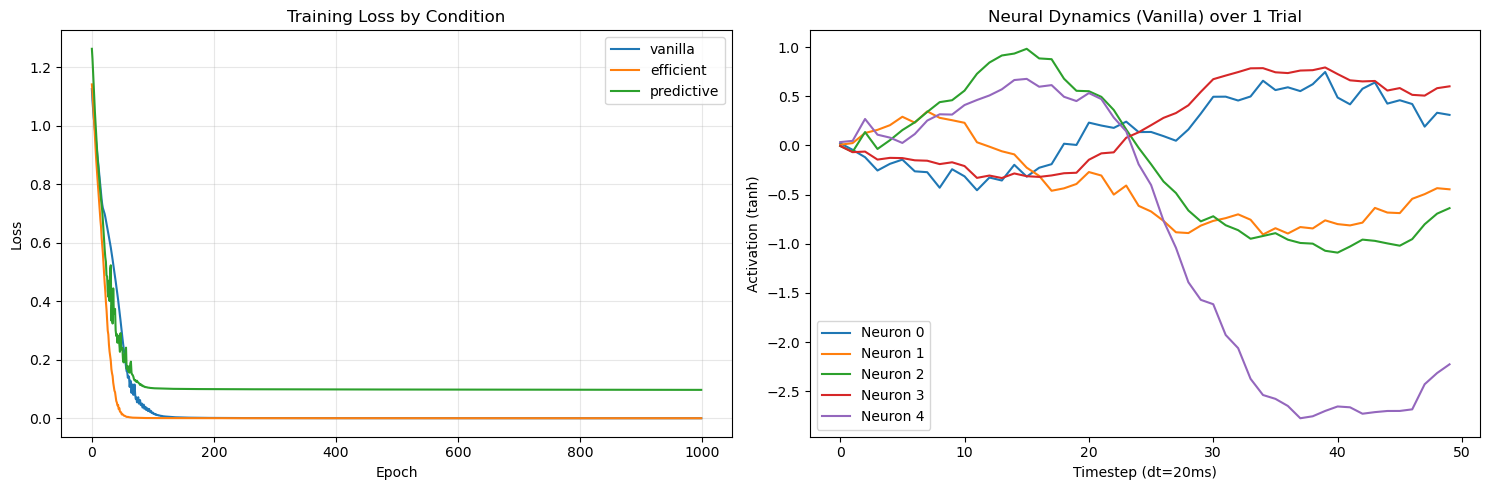

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Training Losses
for cond in conditions:
    axes[0].plot(loss_history[cond], label=cond)
axes[0].set_title("Training Loss by Condition")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Hidden State Dynamics (Vanilla Condition)
vanilla_states = final_hidden_states["vanilla"] # Shape: (50 timesteps, 80 neurons)
# Plotting just the first 5 neurons for clarity
for neuron_idx in range(5):
    axes[1].plot(vanilla_states[:, neuron_idx], label=f"Neuron {neuron_idx}")
axes[1].set_title("Neural Dynamics (Vanilla) over 1 Trial")
axes[1].set_xlabel("Timestep (dt=20ms)")
axes[1].set_ylabel("Activation (tanh)")
axes[1].legend()

plt.tight_layout()
plt.show()

# Save states for Notebook 2
np.save("poc_hidden_states.npy", final_hidden_states)